### 1. Entendimiento del Problema

**Objetivo analítico:** Construir un modelo de clasificación binaria que prediga la probabilidad de que un cliente abandone el banco (Exited=1), permitiendo al área comercial priorizar acciones de retención.

**Pregunta de negocio:** ¿Qué clientes tienen mayor probabilidad de fuga y qué características los definen, para dirigir campañas de retención?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)

# Para interpretabilidad
!pip install shap -q
import shap

## 3. Lectura de Datos

**Dataset:** Bank Customer Churn Modelling (Kaggle) — 10,000 registros de clientes de un banco europeo con variables demográficas, financieras y de comportamiento.

**Variable objetivo:** `Exited` — 1 si el cliente abandonó el banco, 0 si permanece.

> ⚠️ **Nota de privacidad:** El dataset es sintético/público. No contiene datos personales reales identificables. Los campos `CustomerId` y `Surname` serán eliminados en la etapa de limpieza.

In [3]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
import json
business_context = {
    "empresa": "Compañía Financiera",
    "productos": ["Ahorro", "Inversión", "Pensiones", "Seguros"],
    "segmentos_edad": {
        "joven": {"min": 18, "max": 30},
        "adulto": {"min": 31, "max": 50},
        "senior": {"min": 51, "max": 100}
    },
    "costo_adquisicion_cliente_usd": 500,
    "costo_retencion_promedio_usd": 80,
    "reglas_vinculacion": {
        "alta": {"min_productos": 3, "activo": True},
        "media": {"min_productos": 2, "activo": True},
        "baja": {"min_productos": 1, "activo": False}
    },
    "segmento_vida_financiera": {
        "inexperto": {
            "descripcion": "Cliente en etapa temprana de vida financiera, salario bajo relativo a su grupo demográfico",
            "reglas": {
                "edad_max": 30,
                "salario_percentil_max": 40
            },
        },
        "promedio": {
            "descripcion": "Cliente con trayectoria financiera en desarrollo, salario medio",
            "reglas": {
                "edad_min": 18,
                "edad_max": 55,
                "salario_percentil_min": 40,
                "salario_percentil_max": 75
            }
        },
        "experto": {
            "descripcion": "Cliente maduro financieramente, salario alto o edad avanzada con capital acumulado",
            "reglas": {
                "condicion": "edad > 55 OR salario en percentil > 75"
            }
        }
    }
}

# Guardar y releer
with open("business_context.json", "w") as f:
    json.dump(business_context, f, indent=2)

with open("business_context.json", "r") as f:
    ctx = json.load(f)

print(f"Empresa: {ctx['empresa']}")
print(f"Costo de adquirir un cliente: ${ctx['costo_adquisicion_cliente_usd']}")
print(f"Costo de retenerlo: ${ctx['costo_retencion_promedio_usd']}")
print(f"→ Retener es {ctx['costo_adquisicion_cliente_usd'] / ctx['costo_retencion_promedio_usd']:.0f}x más barato que adquirir")
print(f"\nSegmentos vida financiera: {list(ctx['segmento_vida_financiera'].keys())}")

Empresa: Compañía Financiera
Costo de adquirir un cliente: $500
Costo de retenerlo: $80
→ Retener es 6x más barato que adquirir

Segmentos vida financiera: ['inexperto', 'promedio', 'experto']


In [7]:

# 2. LECTURA, LIMPIEZA Y PREPARACIÓN DE DATOS


# 2.1 Inspección inicial
print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✓ Sin valores nulos")

print("\n=== DUPLICADOS ===")
dupes = df.duplicated().sum()
print(f"Duplicados: {dupes}" if dupes > 0 else "✓ Sin duplicados")

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().T

=== FORMA DEL DATASET ===
Filas: 10,000 | Columnas: 11

=== TIPOS DE DATOS ===
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

=== VALORES NULOS ===
✓ Sin valores nulos

=== DUPLICADOS ===
✓ Sin duplicados

=== ESTADÍSTICAS DESCRIPTIVAS ===


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


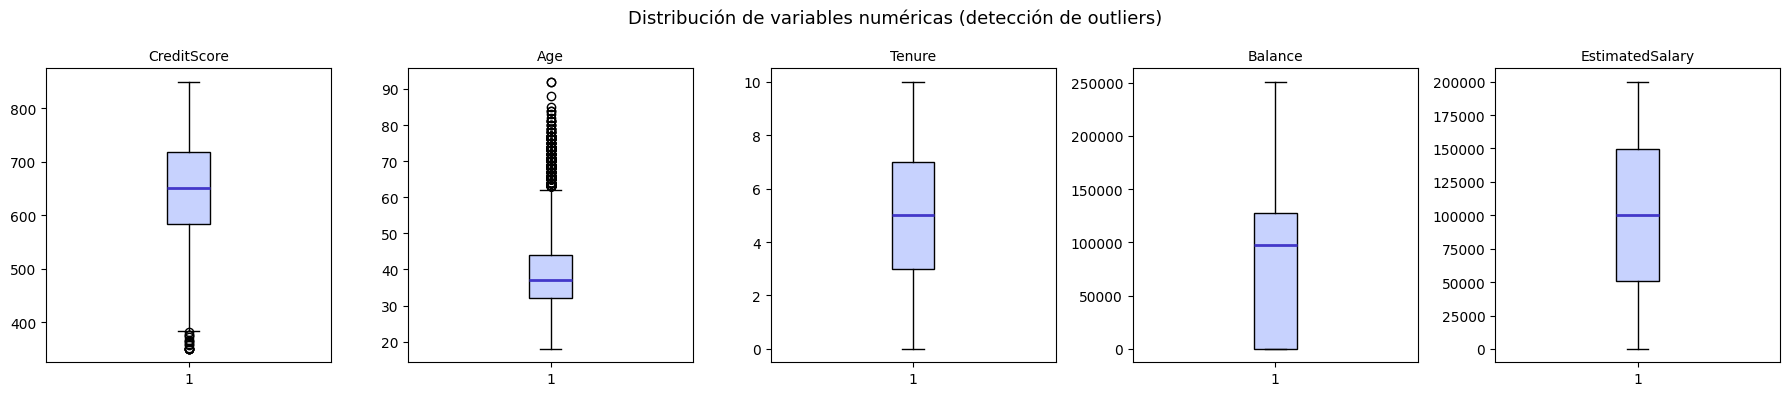


=== OUTLIERS POR IQR ===
CreditScore: 15 outliers (0.1%)
Age: 359 outliers (3.6%)
Tenure: 0 outliers (0.0%)
Balance: 0 outliers (0.0%)
EstimatedSalary: 0 outliers (0.0%)


In [12]:
# --- 2.2 Análisis de outliers ---

numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(1, len(numericas), figsize=(18, 4))
fig.suptitle('Distribución de variables numéricas (detección de outliers)', fontsize=13)

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#c7d2fe'),
                    medianprops=dict(color='#4338ca', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# Identificar outliers con IQR
print("\n=== OUTLIERS POR IQR ===")
for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    pct = len(outliers)/len(df)*100
    print(f"{col}: {len(outliers)} outliers ({pct:.1f}%)")

In [13]:
# 2.3 Codificación de variables categóricas

# Geography: 3 categorías (France, Spain, Germany) → One-Hot Encoding
# Por qué OHE y no Label Encoding: Geography no tiene orden natural.
# Label Encoding (0,1,2) implicaría que Germany > Spain > France, lo cual es falso.

df = pd.get_dummies(df, columns=['Geography'], drop_first=False, dtype=int)

# Gender: binaria → Label Encoding es suficiente
df['Gender'] = (df['Gender'] == 'Male').astype(int)

print("Variables después de codificación:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
df.head(3)

Variables después de codificación:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']

Shape: (10000, 13)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0


In [14]:

# 3. FEATURE ENGINEERING

# variables que capturen patrones de negocio
# que las variables originales no expresan directamente.

# 3.1 Variables derivadas de negocio

# Saldo por producto: clientes con mucho saldo pero pocos productos
# son candidatos a diversificar O a irse a la competencia
df['balance_per_product'] = df['Balance'] / (df['NumOfProducts'] + 1)

# Ratio balance/salario: mide qué tan "engaged" está el cliente financieramente
df['balance_salary_ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# Cliente inactivo con saldo: señal de desconexión — tiene plata pero no interactúa
df['inactive_with_balance'] = ((df['IsActiveMember'] == 0) & (df['Balance'] > 0)).astype(int)

# Cliente senior: mayor propensión a fuga en algunas geografías
df['is_senior'] = (df['Age'] > 55).astype(int)

# Cliente joven sin productos: baja vinculación
df['young_low_products'] = ((df['Age'] < 30) & (df['NumOfProducts'] <= 1)).astype(int)

# Tenure corto: clientes nuevos con mayor riesgo de fuga
df['short_tenure'] = (df['Tenure'] <= 2).astype(int)

# 3.2 Clasificar segmento_vida_financiera usando el JSON
# contexto de negocio del JSON para etiquetar clientes
# percentiles por valores reales calculados del dataset

sal_p40 = df['EstimatedSalary'].quantile(0.40)
sal_p75 = df['EstimatedSalary'].quantile(0.75)

def clasificar_segmento(row, ctx):
    reglas = ctx['segmento_vida_financiera']
    edad = row['Age']
    salario = row['EstimatedSalary']

    if edad <= reglas['inexperto']['reglas']['edad_max'] and salario <= sal_p40:
        return 'inexperto'
    elif edad > 55 or salario > sal_p75:
        return 'experto'
    else:
        return 'promedio'

df['segmento_vida'] = df.apply(lambda row: clasificar_segmento(row, ctx), axis=1)

# Encoding del segmento
segmento_map = {'inexperto': 0, 'promedio': 1, 'experto': 2}
df['segmento_vida_enc'] = df['segmento_vida'].map(segmento_map)

print("Distribución de segmento de vida financiera:")
print(df['segmento_vida'].value_counts())
print(f"\n→ Percentil 40 de salario: ${sal_p40:,.0f}")
print(f"→ Percentil 75 de salario: ${sal_p75:,.0f}")
print(f"\nNuevas variables creadas: {['balance_per_product','balance_salary_ratio','inactive_with_balance','is_senior','young_low_products','short_tenure','segmento_vida_enc']}")

Distribución de segmento de vida financiera:
segmento_vida
promedio     6102
experto      3118
inexperto     780
Name: count, dtype: int64

→ Percentil 40 de salario: $80,238
→ Percentil 75 de salario: $149,388

Nuevas variables creadas: ['balance_per_product', 'balance_salary_ratio', 'inactive_with_balance', 'is_senior', 'young_low_products', 'short_tenure', 'segmento_vida_enc']


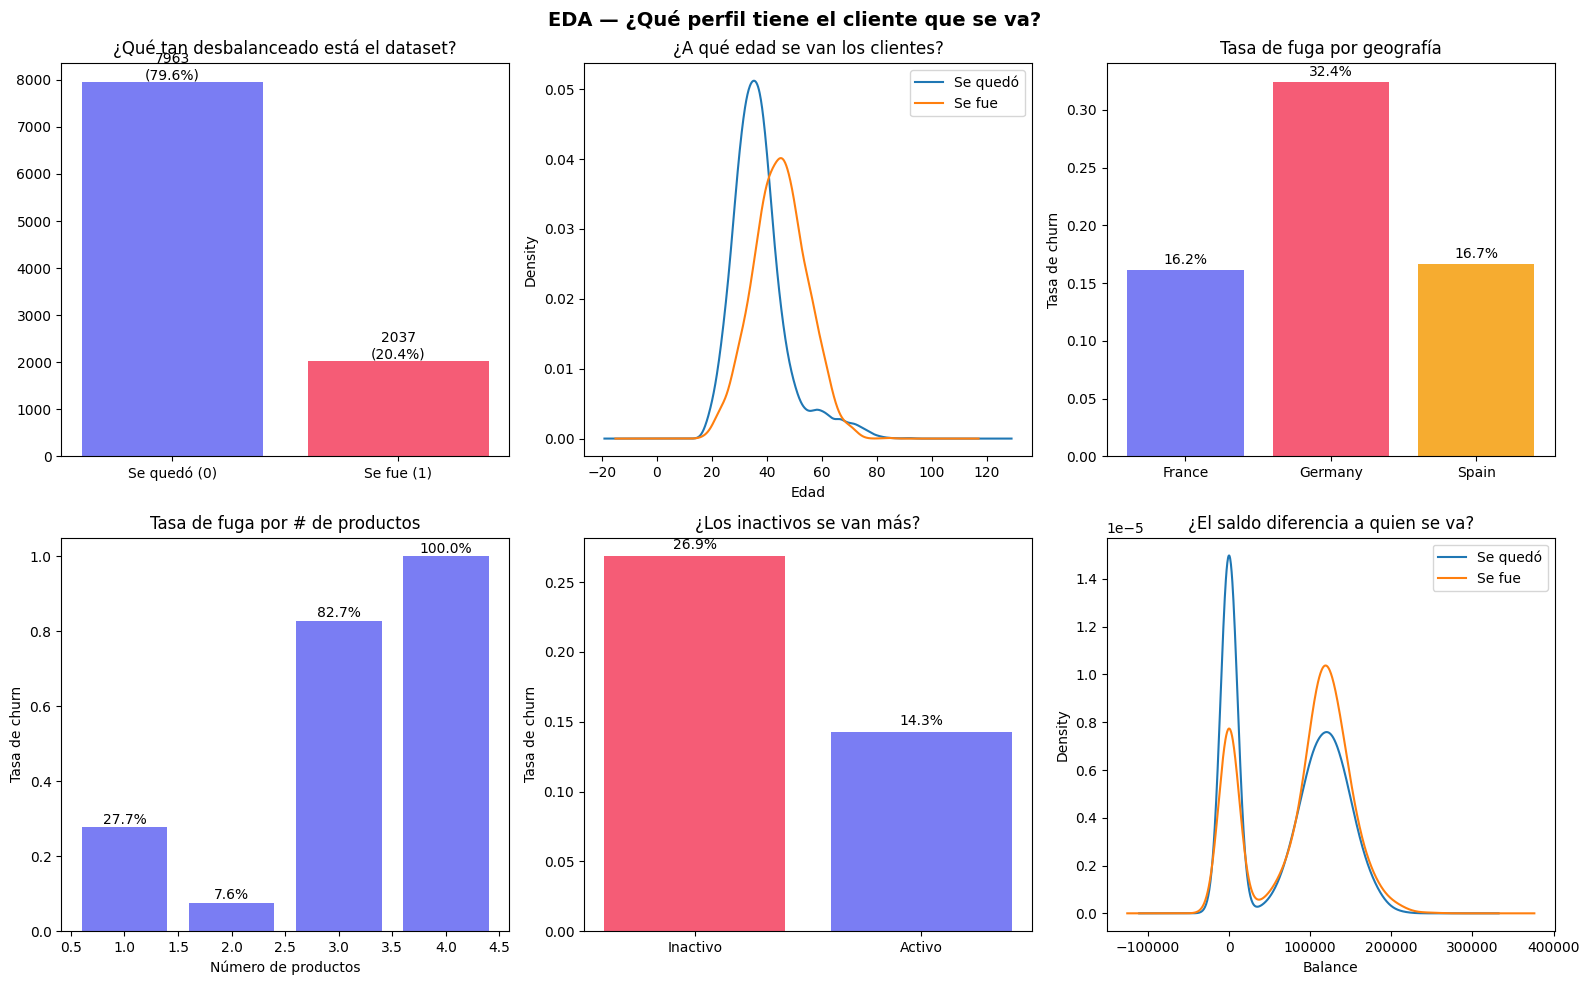

In [15]:

# 4. EDA — ANÁLISIS ORIENTADO A NEGOCIO

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — ¿Qué perfil tiene el cliente que se va?', fontsize=14, fontweight='bold')

# P1: ¿Hay desbalance en la variable objetivo?
churn_rate = df['Exited'].value_counts()
axes[0,0].bar(['Se quedó (0)', 'Se fue (1)'], churn_rate.values,
              color=['#6366f1', '#f43f5e'], alpha=0.85)
axes[0,0].set_title('¿Qué tan desbalanceado está el dataset?')
for i, v in enumerate(churn_rate.values):
    axes[0,0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# P2: ¿La edad importa?
df.groupby('Exited')['Age'].plot(kind='kde', ax=axes[0,1], legend=True)
axes[0,1].set_title('¿A qué edad se van los clientes?')
axes[0,1].legend(['Se quedó', 'Se fue'])
axes[0,1].set_xlabel('Edad')

# P3: ¿Geography importa?
geo_cols = [c for c in df.columns if c.startswith('Geography_')]
geo_churn = {}
for col in geo_cols:
    nombre = col.replace('Geography_', '')
    tasa = df[df[col]==1]['Exited'].mean()
    geo_churn[nombre] = tasa
axes[0,2].bar(geo_churn.keys(), geo_churn.values(), color=['#6366f1','#f43f5e','#f59e0b'], alpha=0.85)
axes[0,2].set_title('Tasa de fuga por geografía')
axes[0,2].set_ylabel('Tasa de churn')
for i, (k, v) in enumerate(geo_churn.items()):
    axes[0,2].text(i, v + 0.005, f'{v:.1%}', ha='center')

# P4: ¿Número de productos?
prod_churn = df.groupby('NumOfProducts')['Exited'].mean()
axes[1,0].bar(prod_churn.index, prod_churn.values, color='#6366f1', alpha=0.85)
axes[1,0].set_title('Tasa de fuga por # de productos')
axes[1,0].set_xlabel('Número de productos')
axes[1,0].set_ylabel('Tasa de churn')
for i, v in enumerate(prod_churn.values):
    axes[1,0].text(prod_churn.index[i], v + 0.01, f'{v:.1%}', ha='center')

# P5: ¿Activo vs inactivo?
activo_churn = df.groupby('IsActiveMember')['Exited'].mean()
axes[1,1].bar(['Inactivo', 'Activo'], activo_churn.values, color=['#f43f5e','#6366f1'], alpha=0.85)
axes[1,1].set_title('¿Los inactivos se van más?')
axes[1,1].set_ylabel('Tasa de churn')
for i, v in enumerate(activo_churn.values):
    axes[1,1].text(i, v + 0.005, f'{v:.1%}', ha='center')

# P6: ¿Balance importa?
df.groupby('Exited')['Balance'].plot(kind='kde', ax=axes[1,2], legend=True)
axes[1,2].set_title('¿El saldo diferencia a quien se va?')
axes[1,2].legend(['Se quedó', 'Se fue'])
axes[1,2].set_xlabel('Balance')

plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:

# 5. PREPARACIÓN PARA MODELADO

# Eliminar columnas no numéricas que ya fueron codificadas
df_model = df.drop(columns=['segmento_vida'])

# Variable objetivo
TARGET = 'Exited'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Features: {len(FEATURES)}")
print(f"Desbalance: {y.value_counts().to_dict()}")
print(f"Tasa de churn: {y.mean():.1%}")

# Split estratificado: mantiene proporción de churn en cada set
# Por qué estratificado: con solo ~20% de churn, un split aleatorio
# podría poner casi todo el churn en train y dejar test sin casos positivos.

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    # 0.176 de 0.85 ≈ 15% del total → train=70%, val=15%, test=15%
)

print(f"\nTrain: {len(X_train):,} ({len(X_train)/len(X):.0%})")
print(f"Val:   {len(X_val):,} ({len(X_val)/len(X):.0%})")
print(f"Test:  {len(X_test):,} ({len(X_test)/len(X):.0%})")

# Verificar que no hay leakage: el escalado se ajusta SOLO en train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform en train
X_val_sc   = scaler.transform(X_val)          # solo transform en val
X_test_sc  = scaler.transform(X_test)         # solo transform en test

print("\n✓ Scaler ajustado solo en train — sin data leakage")

Features: 19
Desbalance: {0: 7963, 1: 2037}
Tasa de churn: 20.4%

Train: 7,004 (70%)
Val:   1,496 (15%)
Test:  1,500 (15%)

✓ Scaler ajustado solo en train — sin data leakage


In [17]:

# 6. MODELADO

# Modelo 1: Regresión Logística — interpretable, baseline sólido
# class_weight='balanced': compensa el desbalance de clases automáticamente
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # penaliza más los errores en clase minoritaria
    random_state=42
)
lr.fit(X_train_sc, y_train)

# Modelo 2: Random Forest — mayor potencia, captura no-linealidades
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

print("✓ Modelos entrenados")
print(f"  - Logistic Regression: {X_train_sc.shape[1]} features")
print(f"  - Random Forest: {rf.n_estimators} árboles, max_depth={rf.max_depth}")

✓ Modelos entrenados
  - Logistic Regression: 19 features
  - Random Forest: 200 árboles, max_depth=10


In [18]:

# 7. MÉTRICAS Y EVALUACIÓN

def evaluar_modelo(nombre, modelo, X_val, y_val, X_test, y_test, threshold=0.5):
    """Evaluación completa de un modelo binario con análisis de umbral."""

    # Probabilidades
    y_val_prob  = modelo.predict_proba(X_val)[:, 1]
    y_test_prob = modelo.predict_proba(X_test)[:, 1]

    # Predicciones con umbral
    y_val_pred  = (y_val_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    # AUC
    auc_val  = roc_auc_score(y_val, y_val_prob)
    auc_test = roc_auc_score(y_test, y_test_prob)

    # KS (Kolmogorov-Smirnov): max diferencia entre distribución de positivos y negativos
    from scipy.stats import ks_2samp
    ks_stat, _ = ks_2samp(
        y_test_prob[y_test == 1],
        y_test_prob[y_test == 0]
    )

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"  AUC  — Val: {auc_val:.4f} | Test: {auc_test:.4f}")
    print(f"  KS   — Test: {ks_stat:.4f}")
    print(f"\n  Reporte en TEST (umbral={threshold}):")
    print(classification_report(y_test, y_test_pred, target_names=['No churn','Churn']))

    return {
        'nombre': nombre,
        'auc_val': auc_val,
        'auc_test': auc_test,
        'ks': ks_stat,
        'y_test_prob': y_test_prob,
        'y_val_prob': y_val_prob
    }

resultados_lr = evaluar_modelo("Regresión Logística", lr, X_val_sc, y_val, X_test_sc, y_test)
resultados_rf = evaluar_modelo("Random Forest",       rf, X_val_sc, y_val, X_test_sc, y_test)


  Regresión Logística
  AUC  — Val: 0.7660 | Test: 0.7736
  KS   — Test: 0.4336

  Reporte en TEST (umbral=0.5):
              precision    recall  f1-score   support

    No churn       0.90      0.72      0.80      1194
       Churn       0.39      0.70      0.50       306

    accuracy                           0.72      1500
   macro avg       0.65      0.71      0.65      1500
weighted avg       0.80      0.72      0.74      1500


  Random Forest
  AUC  — Val: 0.8576 | Test: 0.8525
  KS   — Test: 0.5464

  Reporte en TEST (umbral=0.5):
              precision    recall  f1-score   support

    No churn       0.90      0.88      0.89      1194
       Churn       0.57      0.61      0.59       306

    accuracy                           0.83      1500
   macro avg       0.74      0.75      0.74      1500
weighted avg       0.83      0.83      0.83      1500



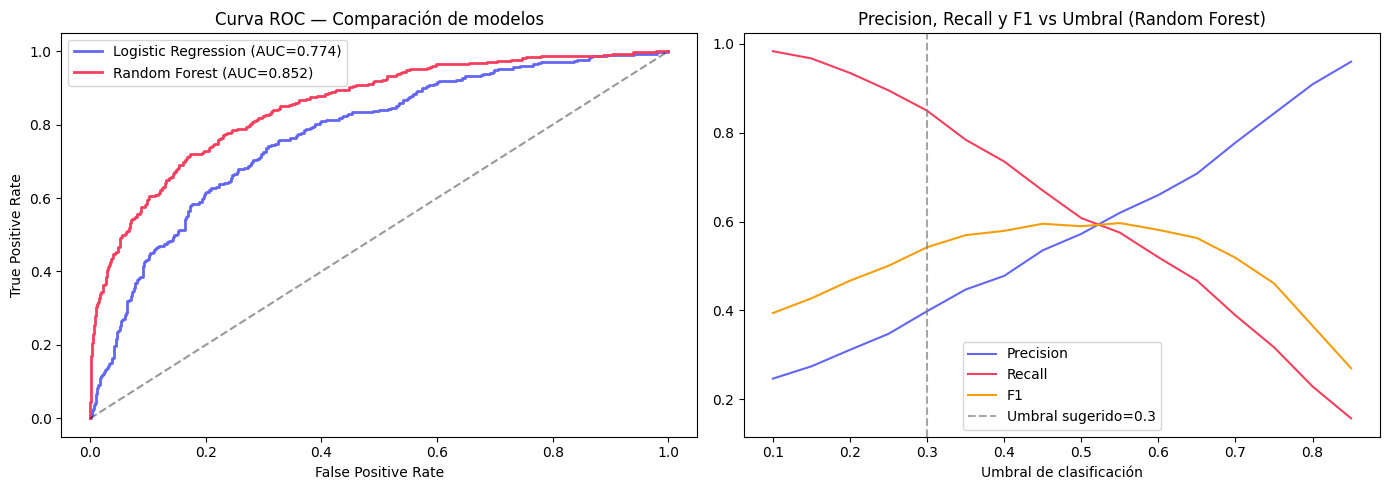


→ Para retención de clientes priorizamos RECALL alto:
  Umbral 0.3: menos falsos negativos (no perdemos clientes en riesgo)
  Costo de un falso negativo: perder un cliente = $500 de adquisición
  Costo de un falso positivo: campaña de retención innecesaria = $80


In [19]:
# Curvas ROC comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for res, color, label in [
    (resultados_lr, '#6366f1', 'Logistic Regression'),
    (resultados_rf, '#f43f5e', 'Random Forest')
]:
    fpr, tpr, _ = roc_curve(y_test, res['y_test_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{label} (AUC={res['auc_test']:.3f})")

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC — Comparación de modelos')
axes[0].legend()

# Análisis de umbral para Random Forest
# Concepto: el umbral por defecto es 0.5 pero en churn
# preferimos recall alto (no perder clientes en riesgo)
# aunque eso aumente los falsos positivos.

thresholds_range = np.arange(0.1, 0.9, 0.05)
precision_list, recall_list, f1_list = [], [], []

for t in thresholds_range:
    preds = (resultados_rf['y_test_prob'] >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    precision_list.append(precision_score(y_test, preds, zero_division=0))
    recall_list.append(recall_score(y_test, preds, zero_division=0))
    f1_list.append(f1_score(y_test, preds, zero_division=0))

axes[1].plot(thresholds_range, precision_list, label='Precision', color='#6366f1')
axes[1].plot(thresholds_range, recall_list,    label='Recall',    color='#f43f5e')
axes[1].plot(thresholds_range, f1_list,        label='F1',        color='#f59e0b')
axes[1].axvline(x=0.3, color='gray', linestyle='--', alpha=0.7, label='Umbral sugerido=0.3')
axes[1].set_xlabel('Umbral de clasificación')
axes[1].set_title('Precision, Recall y F1 vs Umbral (Random Forest)')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ Para retención de clientes priorizamos RECALL alto:")
print("  Umbral 0.3: menos falsos negativos (no perdemos clientes en riesgo)")
print("  Costo de un falso negativo: perder un cliente = $500 de adquisición")
print("  Costo de un falso positivo: campaña de retención innecesaria = $80")

In [20]:

# 8. ESTABILIDAD — PSI (Population Stability Index)

# PSI mide si la distribución de las probabilidades del modelo
# cambió entre train y test. Si cambia mucho, el modelo se degradó.
# PSI < 0.10: estable | 0.10-0.25: alerta | > 0.25: rediseñar

def calcular_psi(score_train, score_test, buckets=10):
    """Calcula PSI entre scores de train y test."""
    breakpoints = np.linspace(0, 1, buckets + 1)
    psi_total = 0
    filas = []

    for i in range(buckets):
        low, high = breakpoints[i], breakpoints[i+1]
        pct_train = np.mean((score_train >= low) & (score_train < high))
        pct_test  = np.mean((score_test  >= low) & (score_test  < high))

        pct_train = max(pct_train, 1e-4)
        pct_test  = max(pct_test,  1e-4)

        psi_bucket = (pct_test - pct_train) * np.log(pct_test / pct_train)
        psi_total += psi_bucket
        filas.append({'Bucket': f'{low:.1f}-{high:.1f}',
                      'Train%': pct_train, 'Test%': pct_test,
                      'PSI_bucket': psi_bucket})

    return psi_total, pd.DataFrame(filas)

train_prob_rf = rf.predict_proba(X_train_sc)[:, 1]
test_prob_rf  = resultados_rf['y_test_prob']

psi_valor, psi_df = calcular_psi(train_prob_rf, test_prob_rf)

print(f"PSI del Random Forest: {psi_valor:.4f}")
if psi_valor < 0.10:
    print("✓ Modelo ESTABLE — distribución consistente entre train y test")
elif psi_valor < 0.25:
    print("⚠ ALERTA — monitorear el modelo en producción")
else:
    print("✗ INESTABLE — considerar reentrenamiento")

print("\nDetalle por bucket:")
print(psi_df.to_string(index=False))

PSI del Random Forest: 0.0524
✓ Modelo ESTABLE — distribución consistente entre train y test

Detalle por bucket:
 Bucket   Train%    Test%  PSI_bucket
0.0-0.1 0.192747 0.185333    0.000291
0.1-0.2 0.248001 0.202000    0.009438
0.2-0.3 0.161051 0.177333    0.001568
0.3-0.4 0.095374 0.121333    0.006249
0.4-0.5 0.078241 0.097333    0.004169
0.5-0.6 0.054540 0.056000    0.000039
0.6-0.7 0.045545 0.058667    0.003322
0.7-0.8 0.042262 0.050667    0.001525
0.8-0.9 0.044974 0.038000    0.001175
0.9-1.0 0.037264 0.013333    0.024596


Shape shap_churn: (500, 19, 2)
Número de features: 19


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

<Figure size 1000x800 with 0 Axes>

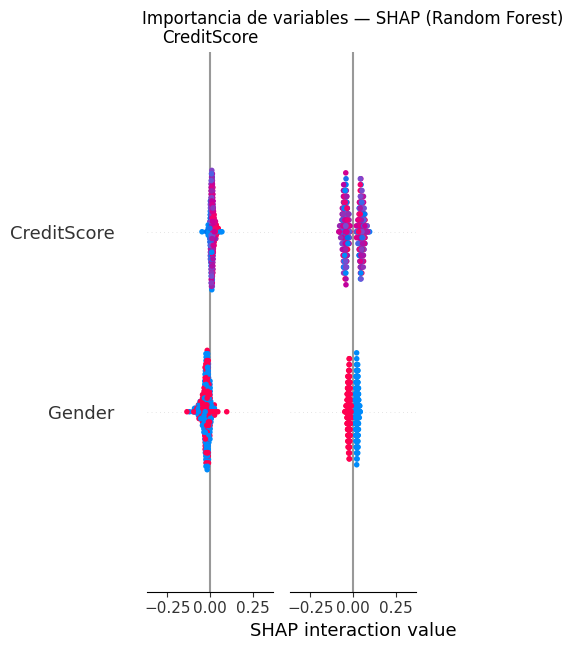

In [25]:
# 9. INTERPRETABILIDAD — SHAP

sample_size = 500
X_shap = pd.DataFrame(X_test_sc, columns=FEATURES).sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_churn = shap_values[1]
else:
    shap_churn = shap_values

print(f"Shape shap_churn: {shap_churn.shape}")
print(f"Número de features: {len(FEATURES)}")

# Gráfico SHAP summary (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_churn,
    X_shap,
    feature_names=FEATURES,
    show=False,
    plot_size=None
)
plt.title('Importancia de variables — SHAP (Random Forest)', pad=20)
plt.tight_layout()
plt

In [27]:

# 10. RECOMENDACIONES DE NEGOCIO


# Aplicar modelo a todo el dataset con umbral 0.3
X_full_sc = scaler.transform(df_model[FEATURES])
df['prob_churn'] = rf.predict_proba(X_full_sc)[:, 1]
df['riesgo']     = pd.cut(df['prob_churn'],
                           bins=[0, 0.3, 0.6, 1.0],
                           labels=['Bajo', 'Medio', 'Alto'])

print("=== SEGMENTACIÓN POR RIESGO DE FUGA ===\n")
resumen = df.groupby('riesgo').agg(
    clientes=('prob_churn', 'count'),
    prob_media=('prob_churn', 'mean'),
    balance_medio=('Balance', 'mean'),
    edad_media=('Age', 'mean'),
    activos_pct=('IsActiveMember', 'mean')
).round(2)
print(resumen)

costo_retencion = ctx['costo_retencion_promedio_usd']
costo_adquisicion = ctx['costo_adquisicion_cliente_usd']

alto_riesgo = (df['riesgo'] == 'Alto').sum()
ahorro_potencial = alto_riesgo * (costo_adquisicion - costo_retencion)

print(f"\n=== IMPACTO ECONÓMICO ===")
print(f"Clientes de alto riesgo identificados: {alto_riesgo:,}")
print(f"Ahorro potencial si se retienen: ${ahorro_potencial:,.0f} USD")
print(f"(vs costo de reemplazarlos a ${costo_adquisicion} c/u)")

print("""
=== ACCIONES RECOMENDADAS POR SEGMENTO ===

 ALTO RIESGO (prob > 0.6):
   → Contacto proactivo por asesor en < 48 horas
   → Oferta personalizada: producto adicional o beneficio exclusivo
   → Priorizar clientes con Balance alto (mayor valor en riesgo)

 RIESGO MEDIO (0.3 - 0.6):
   → Campaña de engagement digital (email, app)
   → Recordatorio de beneficios no utilizados
   → Encuesta de satisfacción para detectar señales tempranas

 BAJO RIESGO (< 0.3):
   → Mantener experiencia actual
   → Oportunidad de cross-sell (más productos = menor churn)
   → Programa de referidos

 HALLAZGOS CLAVE DEL MODELO:
   → Clientes inactivos con saldo alto: perfil de mayor riesgo
   → Germany tiene tasa de churn ~2x vs France y Spain
   → Clientes con 3+ productos tienen churn casi nulo
   → Edad 40-60: ventana crítica de retención
""")

=== SEGMENTACIÓN POR RIESGO DE FUGA ===

        clientes  prob_media  balance_medio  edad_media  activos_pct
riesgo                                                              
Bajo        5946        0.15       63873.87       35.51         0.59
Medio       2393        0.43       95310.75       41.34         0.49
Alto        1661        0.78       94513.08       47.66         0.29

=== IMPACTO ECONÓMICO ===
Clientes de alto riesgo identificados: 1,661
Ahorro potencial si se retienen: $697,620 USD
(vs costo de reemplazarlos a $500 c/u)

=== ACCIONES RECOMENDADAS POR SEGMENTO ===

 ALTO RIESGO (prob > 0.6):
   → Contacto proactivo por asesor en < 48 horas
   → Oferta personalizada: producto adicional o beneficio exclusivo
   → Priorizar clientes con Balance alto (mayor valor en riesgo)

 RIESGO MEDIO (0.3 - 0.6):
   → Campaña de engagement digital (email, app)
   → Recordatorio de beneficios no utilizados
   → Encuesta de satisfacción para detectar señales tempranas

 BAJO RIESGO (< 0.

### Despliegue sugerido
El modelo puede servirse como API REST (FastAPI + joblib) integrada al CRM,
donde el asesor recibe una alerta automática cuando un cliente supera el
umbral de probabilidad de churn ≥ 0.3.

### Anexo — Ejemplo de despliegue como API (no ejecutable en Colab)

**1. Guardar el modelo entrenado:**

In [ ]:
# Celda Python (no ejecutar)
import joblib
joblib.dump(rf, 'modelo_churn.pkl')
joblib.dump(scaler, 'scaler_churn.pkl')

**2. Código de la API:**

In [ ]:
# Celda Python (no ejecutar)
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()
modelo = joblib.load('modelo_churn.pkl')
scaler = joblib.load('scaler_churn.pkl')

@app.post("/predecir")
def predecir(data: dict):
    X = np.array(data["features"]).reshape(1, -1)
    X_scaled = scaler.transform(X)
    proba = modelo.predict_proba(X_scaled)[0][1]
    return {
        "probabilidad_churn": round(float(proba), 4),
        "clasificacion": "ALTO RIESGO" if proba >= 0.3 else "BAJO RIESGO",
        "umbral_usado": 0.3
    }

**3. Para ejecutar localmente:**
```bash
pip install fastapi uvicorn
uvicorn api:app --reload
```